In [1]:
import tensorflow as tf
import numpy as np

In [2]:
from tensorflow.keras.datasets import imdb

In [3]:
max_features =10000 #Vocabulary size

In [4]:
(x_train, y_train), (x_test, y_test)=imdb.load_data(num_words=max_features)

In [5]:
x_train.shape, x_test.shape,y_train.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [6]:
len(x_train[5])

43

In [7]:
type(x_train),type(x_test)

(numpy.ndarray, numpy.ndarray)

In [ ]:
# Thsi dataset already comes with One Hot Representation

# Example:
"""
    from tensorflow.keras.preprocessing.text import one_hot
    
    sent=[  'the glass of milk',
     'the glass of juice',
     'the cup of tea',
    'I am a good boy',
     'I am a good developer',
     'understand the meaning of words',
     'your videos are good',]
   
    voc_size=10000  ## Define the vocabulary size

    one_hot_repr=[one_hot(words,voc_size)for words in sent]
    OUTPUt : one_hot_repr
                [[6186, 6775, 637, 4895],
                 [6186, 6775, 637, 5462],
                 [6186, 7872, 637, 7943],
                 [7793, 3440, 840, 9701, 4879],
                 [7793, 3440, 840, 9701, 1294],
                 [932, 6186, 733, 637, 1731],
                 [2258, 439, 5397, 9701]]
    
    
"""

In [11]:
# For my understanding
word_index=imdb.get_word_index()
reverse_word_index= {value:key for key,value in word_index.items()}

In [12]:
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [13]:
sample_review=x_train[0]

In [14]:
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in sample_review])
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [15]:
max_len = max(len(review) for review in x_train)
print(f"Maximum review length of x_train : {max_len} words")

Maximum review length of x_train : 2494 words


In [16]:
l1=[len(seq) for seq in x_train]
print("*"*10,"x_train","*"*10 )
print("max lenght:", np.max(l1))
print("Mean :", np.mean(l1))
print("median :", np.median(l1))
print("95 percentile :", np.percentile(l1, 95))


********** x_train **********
max lenght: 2494
Mean : 238.71364
median : 178.0
95 percentile : 610.0


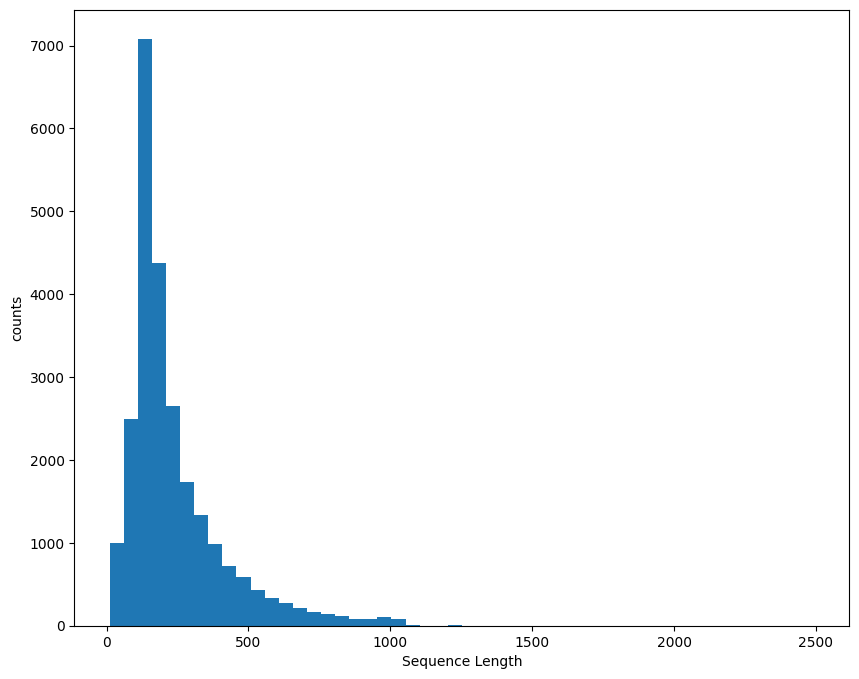

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.hist(l1,bins=50)
plt.xlabel("Sequence Length")
plt.ylabel('counts')
plt.show()

In [18]:
l2=[len(seq) for seq in x_test]
print("*"*10,"x_test","*"*10 )
print("max lenght:", np.max(l2))
print("Mean :", np.mean(l2))
print("median :", np.median(l2))
print("95 percentile :", np.percentile(l2, 95))

********** x_test **********
max lenght: 2315
Mean : 230.8042
median : 174.0
95 percentile : 586.0


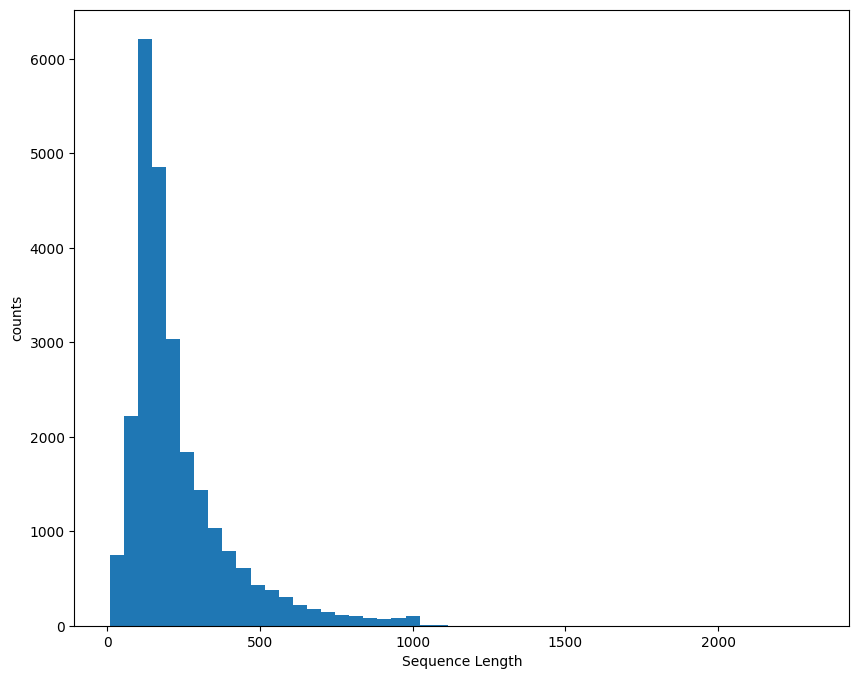

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.hist(l2,bins=50)
plt.xlabel("Sequence Length")
plt.ylabel('counts')
plt.show()

In [20]:
y_train

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [21]:
from tensorflow.keras.preprocessing import sequence

max_len_train=610
max_len_test=586
x_train=sequence.pad_sequences(x_train,maxlen=max_len_train)
x_test=sequence.pad_sequences(x_test,maxlen=max_len_test)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [23]:
model=Sequential()
model.add(Embedding(max_features,128,input_length=max_len))
model.add(SimpleRNN(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

D:\envs\tf_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
## Create an instance of EarlyStoppping Callback
from tensorflow.keras.callbacks import EarlyStopping
earlystoping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [27]:
history=model.fit(x=x_train,y=y_train,epochs=10,batch_size=32,validation_split=0.2,callbacks=[earlystoping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 114ms/step - accuracy: 0.5691 - loss: 951643840.0000 - val_accuracy: 0.5166 - val_loss: 0.6827
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.6775 - loss: 0.5891 - val_accuracy: 0.6752 - val_loss: 0.5878
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.7857 - loss: 0.4542 - val_accuracy: 0.7158 - val_loss: 0.5383
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.8574 - loss: 0.3342 - val_accuracy: 0.7836 - val_loss: 0.4796
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.8903 - loss: 0.2685 - val_accuracy: 0.7828 - val_loss: 0.5270
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.9215 - loss: 0.2016 - val_accuracy: 0.7992 - val_loss: 0.5173
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.9327 - loss: 0.1776 - val_accuracy: 0.8074 - val_loss: 0.6296
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.9413 -

In [28]:
model.save('simple_rnn_indb.h5')

In [29]:
model.save('simple_rnn_imdb.keras')